In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

Création de deux "tableaux" Panda pour les données d'entrainement et de validation.
Logiquement on va appliquer le même traitement sur les deux jeux de données.

Ensuite, nous allons afficher un résumé de nos données d'entrainement afin d'avoir un visuel de la moyenne, le max, le quartiles, ...

In [2]:
train_raw = pd.read_csv('Data/train.csv', index_col = 'Id')
validation_raw = pd.read_csv('Data/test.csv', index_col = 'Id')

# descriptive statistics summary
train_raw['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Est-ce que notre distribution est normalement distribué ?
Nous allons effectuer un Shapiro-Wilk Test afin de le savoir.

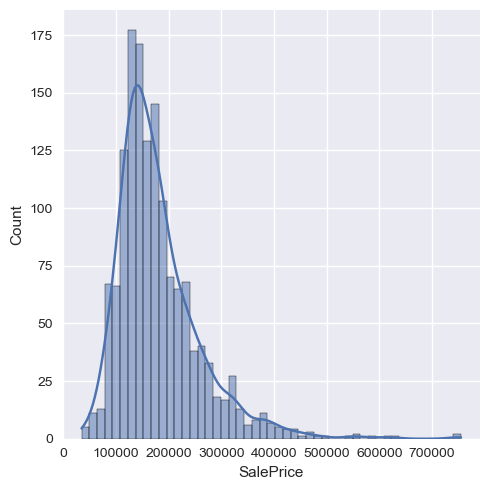

In [3]:
# distribution plot with normal fit
ax = sns.displot(data = train_raw['SalePrice'], kde=True)
plt.show()

The assocated p-value is : 3.2061412312021656e-33
With a threshold α = 0.05, we reject the null hypothesis


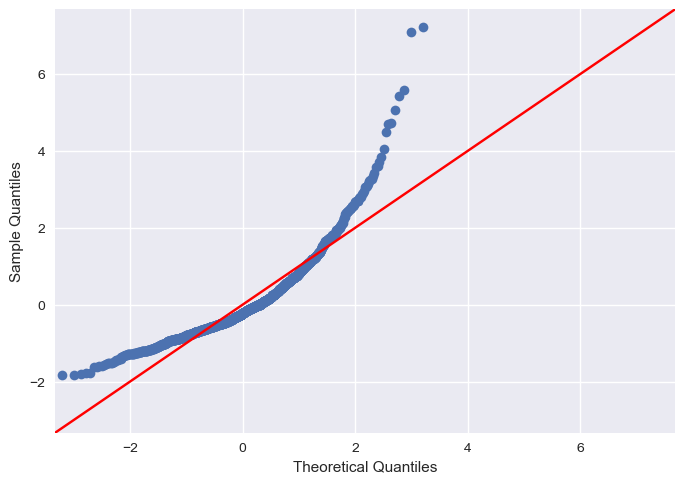

In [4]:
# Shapiro-Wilk Test for normality together with the Q-Q plot
alpha = 0.05
W, p = stats.shapiro(train_raw['SalePrice'])

print('The assocated p-value is : ' + str(p))

if p < alpha : 
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else : 
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')
    
qqplot(train_raw['SalePrice'], dist = stats.distributions.norm, fit = True, line = '45')
plt.show()

La distribution n'est pas linéaire car il y a des valeurs extrême qui faussent les quantiles (certains biens vendus très chers en l'occurrence) . On va donc utilisé une formule logarithmique afin de pondéré et rendre l'impact des valeurs extrêmes plus proportionnelles.

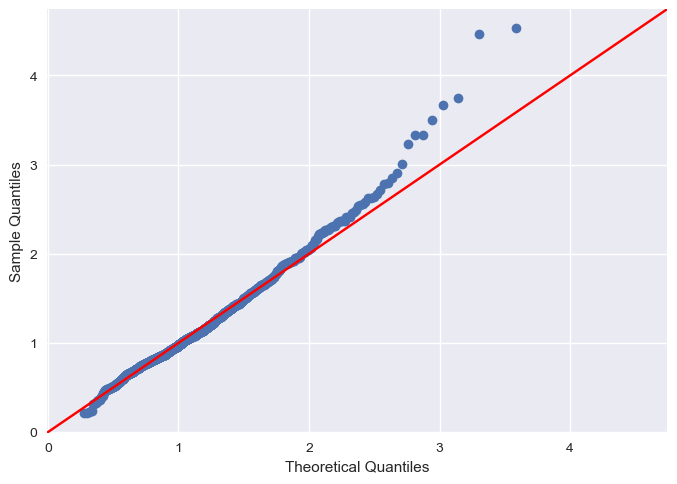

In [5]:
qqplot(train_raw['SalePrice'], dist = stats.distributions.lognorm, fit = True, line = '45')
plt.show()

Malgré la fonction logarithmique , certaines valeurs extrême émerge encore (maison chères) … ces données devront être analysées avec un éclairage métier afin de savoir si elles sont correctes. (par exemple une maison vendue en 99 en franc francais seraient super cher par rapport à une maison vendue en 2000 en euros)

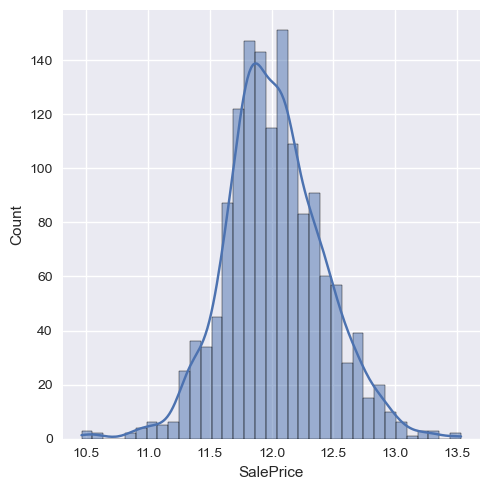

In [6]:
# new variable target which is the logarithm of the SalePrice
target = np.log1p(train_raw['SalePrice'])

# distribution plot
ax = sns.displot(data = target, kde=True)
plt.show()

On divise ensuite les variables en 3 catégories : ...

In [7]:
qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
              'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
              'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
              'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
              'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
              'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish', 
              'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
              'SaleType', 'SaleCondition', 'MoSold']

quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',  
               'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 
               'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 
               'PoolArea', 'MiscVal']

date = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

In [8]:
data_raw = pd.concat([train_raw, validation_raw])

En ce qui concerne le traitement des données manquante , il faut être prudent et distinguer plusieurs cas, qui nécessiteront potentiellement des traitements différents.  Par exemple le nombre de mètres carrés d'une piscine: 0 veux dire qu'il n'y a pas de piscine ou alors qu'on ne sait pas sa taille? Dans ce cas on peut déduire que si il y a une piscine mais que son aire est à 0, on a pas l'info donc on peut y mettre la médiane par exemple.

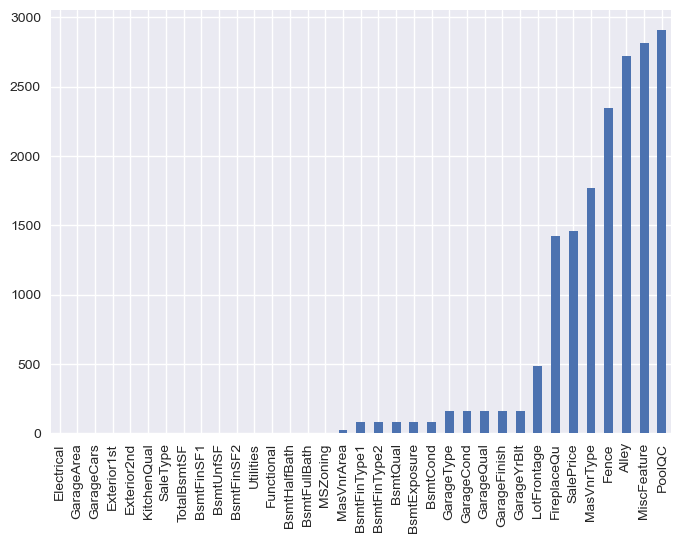

In [9]:
def plot_missing(data):

    missing = data.isnull().sum()
    missing = missing[missing > 0]
    
    if missing.empty:
        print('No missing values')
    else :
        missing.sort_values(inplace=True)
        missing.plot.bar()
    
        plt.show()

plot_missing(data_raw)

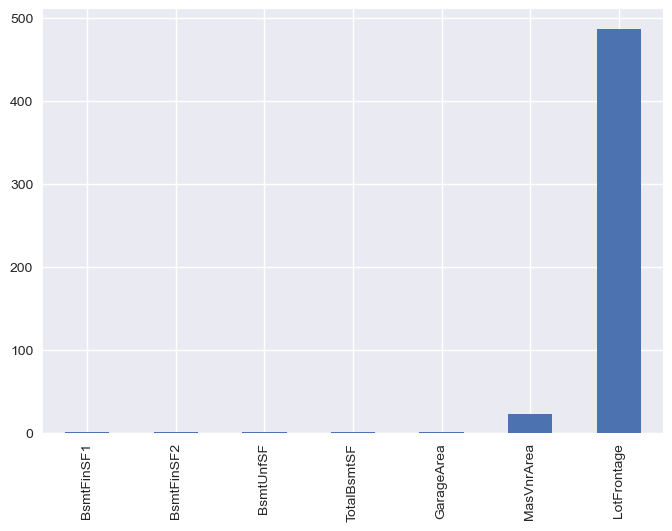

In [16]:
plot_missing(data_raw[quantitative])

In [11]:
# For quantitative variables, we will fill columns with 0
def fill_missing_with_constant(data, columns, constant):
    
    data_clean = data.copy()
    
    for c in columns :
        
        if data_clean[c].isnull().any():
            data_clean[c] = data_clean[c].fillna(constant)
    
    return data_clean

Voir les variables quantitatives manquantes :

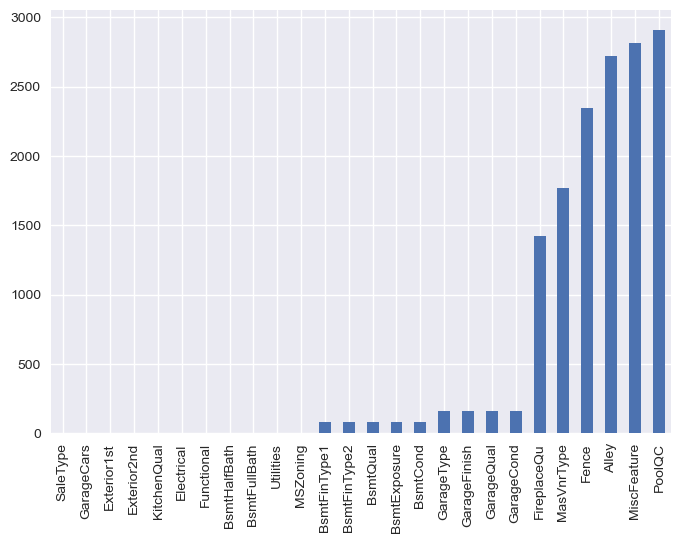

In [12]:
plot_missing(data_raw[qualitative])

Dates:
Données manquantes dans Garageyrbldt: on  met l'année de contruction de la maison (car en principe le garage est, au pire, aussi vieux que la maison mais pas plus)
 
afin de pouvoir exploiter des dates de façon mathématiques: il faut les transformer en nombre d'années.
1: année de vente - année de construction = nombre d'années qu'à la maison
2:  année de vente - année de rénovation =nombre d'années depuis la dernières rénovation
3: année de vente- année de construction garage = nombre d'années depuis la construction du garage

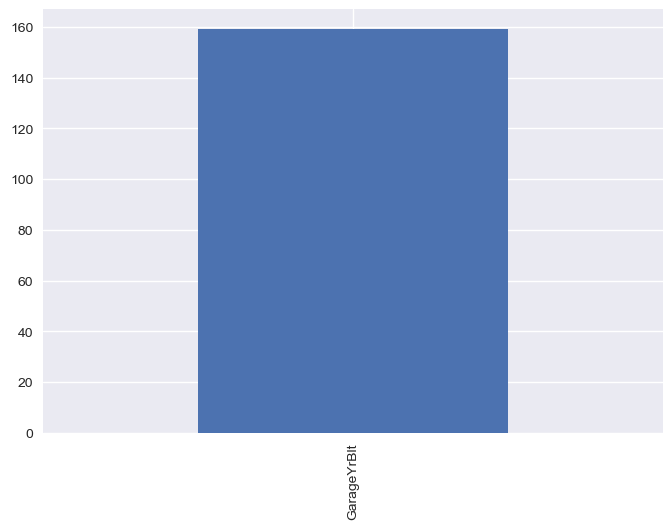

In [13]:
plot_missing(data_raw[date])

In [14]:
# For date variables, we will fill the missing values using the values from another column
def fill_missing_with_column(data, missing, column) :
    
    data_clean = data.copy()
    
    data_clean[missing] = np.where(data_clean[missing].isnull(), data_clean[column], data_clean[missing])
    
    return data_clean

## Transformation des dates pour en tirer des données numériques utilisables 

Transformer des dates absolues en durées relatives à la date de vente (YrSold) :

- Années depuis construction
- Années depuis rénovation
- Années depuis construction du garage

In [17]:
def compute_differences_to_year_sold(data) :
    
    data_clean = data.copy()
    
    data_clean['YearBuilt'] = data_clean['YrSold'] - data_clean['YearBuilt']
    data_clean['YearRemodAdd'] = data_clean['YrSold'] - data_clean['YearRemodAdd']
    data_clean['GarageYrBlt'] = data_clean['YrSold'] - data_clean['GarageYrBlt']
    
    return data_clean

## Nettoyage
On centralise toutes les étapes de nettoyage des données dans une seule fonction appelée clean(), afin de l’exécuter d’un seul coup sur le jeu de données brut (data_raw), qui contient à la fois le train et le test.

In [18]:
def clean(data) :
    
    data_clean = data.copy()
    
    # imputing missing variables
    data_clean = fill_missing_with_constant(data_clean, columns = quantitative, constant = 0)
    data_clean = fill_missing_with_constant(data_clean, columns = qualitative, constant = 'NA')
    data_clean = fill_missing_with_column(data_clean, missing = ['GarageYrBlt'], column = ['YearBuilt'])

    # transform date columns
    data_clean = compute_differences_to_year_sold(data_clean)
    
    return data_clean

On lance le process de nettoyage

In [19]:
data_clean = clean(data_raw)

data_clean.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500.0
2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500.0
3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,Inside,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500.0
4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,Corner,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000.0
5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,FR2,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000.0
